#### Data Modeling & Initial EDA (DuckDB)

**Objective**  
Transform raw user-level A/B test data into dimensional model  
(dim + fact tables + aggregated views)

**Why DuckDB?**
- Fast analytical SQL
- Parquet/CSV native
- No server needed
- Prepares for BigQuery/Snowflake-style thinking

#### Installs & imports

In [13]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("DuckDB version:", duckdb.__version__)

DuckDB version: 1.4.4


#### Create DuckDB connection & load raw data

In [14]:
con = duckdb.connect(database=':memory:')

# Load CSV directly into DuckDB table
con.execute("""
    CREATE OR REPLACE TABLE raw_events AS
    SELECT *
    FROM read_csv_auto('../data/raw_data/gaming_ab_test_raw_100k_v2.csv',
                       types={'install_date': 'TIMESTAMP'})
""")

# Quick check
print("Raw table columns:")
display(con.sql("DESCRIBE raw_events").df())

print("\nRow count:", con.sql("SELECT COUNT(*) FROM raw_events").fetchone()[0])
print("First 3 rows:")
display(con.sql("SELECT * FROM raw_events LIMIT 3").df())

Raw table columns:


,column_name,column_type,null,key,default,extra
0,user_id,BIGINT,YES,None,None,None
1,variant,VARCHAR,YES,None,None,None
2,install_date,TIMESTAMP,YES,None,None,None
3,d1_retention,BIGINT,YES,None,None,None
4,d7_retention,BIGINT,YES,None,None,None
5,d30_retention,BIGINT,YES,None,None,None
6,revenue,DOUBLE,YES,None,None,None
7,sessions_d1,BIGINT,YES,None,None,None
8,levels_d7,BIGINT,YES,None,None,None
9,is_payer,BIGINT,YES,None,None,None



Row count: 100000
First 3 rows:


,user_id,variant,install_date,d1_retention,d7_retention,d30_retention,revenue,sessions_d1,levels_d7,is_payer
0,1,A,2023-04-01 00:06:29.751009,1,1,0,0.60,1,14,0
1,2,B,2023-04-01 00:08:56.022639,1,0,1,0.93,5,22,0
2,3,B,2023-04-01 00:21:26.287279,1,0,0,0.45,1,18,0


#### Dimension table: dim_users



In [15]:
con.execute("""
    CREATE OR REPLACE TABLE dim_users AS
    SELECT
        user_id,
        variant,
        install_date,
        DATE_TRUNC('day', install_date)   AS install_day,
        DATE_TRUNC('week', install_date)  AS install_week,
        DATE_PART('year', install_date)   AS install_year,
        DATE_PART('month', install_date)  AS install_month,
        DATE_PART('dow', install_date)    AS install_weekday   -- 0=Sunday, 6=Saturday
    FROM raw_events;
""")

print("dim_users created")
display(con.sql("SELECT * FROM dim_users LIMIT 5").df())

dim_users created


,user_id,variant,install_date,install_day,install_week,install_year,install_month,install_weekday
0,1,A,2023-04-01 00:06:29.751009,2023-04-01,2023-03-27,2023,4,6
1,2,B,2023-04-01 00:08:56.022639,2023-04-01,2023-03-27,2023,4,6
2,3,B,2023-04-01 00:21:26.287279,2023-04-01,2023-03-27,2023,4,6
3,4,B,2023-04-01 00:35:40.336226,2023-04-01,2023-03-27,2023,4,6
4,5,A,2023-04-01 00:37:25.383588,2023-04-01,2023-03-27,2023,4,6


#### Fact table: fact_user_metrics



In [16]:
con.execute("""
    CREATE OR REPLACE TABLE fact_user_metrics AS
    SELECT
        user_id,
        variant,
        d1_retention,
        d7_retention,
        d30_retention,
        revenue,
        sessions_d1,
        levels_d7,
        is_payer,
        
        -- Derived columns
        CASE WHEN revenue > 0 THEN 1 ELSE 0 END AS has_revenue,
        CASE 
            WHEN revenue >= 10 THEN 'High'
            WHEN revenue >= 1  THEN 'Medium'
            ELSE 'Low/Zero'
        END AS revenue_segment
    FROM raw_events;
""")

print("fact_user_metrics created")
display(con.sql("""
    SELECT variant, COUNT(*), AVG(revenue), AVG(d7_retention)
    FROM fact_user_metrics
    GROUP BY variant
""").df())

fact_user_metrics created


,variant,count_star(),avg(revenue),avg(d7_retention)
0,A,49934,0.496227,0.250931
1,B,50066,0.576859,0.322614


#### Aggregated view: daily cohorts



In [23]:
con.execute("""
    CREATE OR REPLACE TABLE cohort_daily AS
    SELECT
        d.install_day,
        f.variant,
        COUNT(*)                                          AS cohort_size,
        ROUND(AVG(f.d1_retention)  * 100, 2)              AS retention_d1_pct,
        ROUND(AVG(f.d7_retention)  * 100, 2)              AS retention_d7_pct,
        ROUND(AVG(f.d30_retention) * 100, 2)              AS retention_d30_pct,
        ROUND(AVG(f.revenue), 3)                          AS avg_revenue,
        ROUND(AVG(f.sessions_d1), 2)                      AS avg_sessions_d1,
        ROUND(AVG(f.levels_d7), 2)                        AS avg_levels_d7,
        ROUND(AVG(f.is_payer) * 100, 2)                   AS payer_conversion_pct
    FROM dim_users d
    JOIN fact_user_metrics f USING (user_id)
    GROUP BY d.install_day, f.variant
    ORDER BY d.install_day, f.variant;
""")

#### Overall A/B KPI summary + bar chart



In [18]:
df_summary = con.sql("""
    SELECT 
        variant,
        COUNT(*)                                  AS users,
        ROUND(AVG(d1_retention)*100,  1)          AS ret_d1_pct,
        ROUND(AVG(d7_retention)*100,  1)          AS ret_d7_pct,
        ROUND(AVG(d30_retention)*100, 1)          AS ret_d30_pct,
        ROUND(AVG(revenue), 3)                    AS avg_revenue_usd,
        ROUND(AVG(sessions_d1), 2)                AS avg_sessions_d1,
        ROUND(AVG(levels_d7), 2)                  AS avg_levels_d7,
        ROUND(AVG(is_payer)*100, 2)               AS payer_pct
    FROM fact_user_metrics
    GROUP BY variant
    ORDER BY variant
""").df()

print("Overall A vs B summary:")
display(df_summary)

Overall A vs B summary:


,variant,users,ret_d1_pct,ret_d7_pct,ret_d30_pct,avg_revenue_usd,avg_sessions_d1,avg_levels_d7,payer_pct
0,A,49934,44.6,25.1,10.1,0.496,2.68,14.99,2.76
1,B,50066,50.0,32.3,15.4,0.577,3.11,18.58,5.03


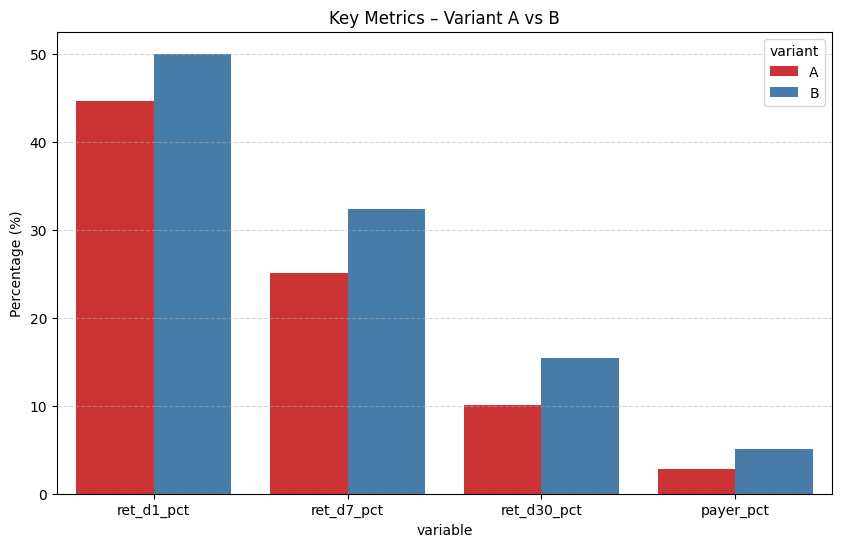

In [19]:
# Visualization
metrics = ['ret_d1_pct', 'ret_d7_pct', 'ret_d30_pct', 'payer_pct']
df_melt = df_summary.melt(id_vars='variant', value_vars=metrics)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x='variable', y='value', hue='variant', palette='Set1')
plt.title('Key Metrics – Variant A vs B')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

#### Export clean tables (Parquet – efficient & future-proof)

In [22]:
import os
os.makedirs('../data/processed_data', exist_ok=True)

con.execute("COPY dim_users         TO '../data/processed_data/dim_users.parquet'         (FORMAT PARQUET)")
con.execute("COPY fact_user_metrics TO '../data/processed_data/fact_user_metrics.parquet' (FORMAT PARQUET)")
con.execute("COPY cohort_daily      TO '../data/processed_data/cohort_daily.parquet'      (FORMAT PARQUET)")

print("Clean Parquet files exported to ../data/processed_data/")

Clean Parquet files exported to ../data/processed_data/
